In [2]:
import pandas as pd

real_df = pd.read_excel(
    "/content/reviews_export.xlsx",
    sheet_name="review"
)

In [3]:
real_df.head()

,id,product_id,site_name,source_review_id,rating,title,review_text,author_name,verified_purchase,helpful_count,review_date,issue,review_images,created_at,updated_at
0,1,1,target,47718208-a57b-465f-b818-ed71e8a349d7,5,Awesome price and quality,These look almost identical to a pair of crate...,Alex,1,0,2026-06-06,NaN,NaN,2026-06-08 13:15:54.510775,2026-06-08 13:15:54.510775
1,2,1,target,a71da4c4-f9a3-4358-b610-65534f8ef62e,4,Narrow Pillowcase,Nice sheets but pillowcases are very narrow,Cheryle,1,0,2026-06-05,NaN,NaN,2026-06-08 13:15:54.512775,2026-06-08 13:15:54.512775
2,3,1,target,e11f3ffb-480f-43ee-af71-7b33c670d573,5,Just Right,Good quality cotton sheets. So hard to find th...,Nina,1,0,2026-06-05,NaN,NaN,2026-06-08 13:15:54.512775,2026-06-08 13:15:54.512775
3,4,1,target,e0f8f8a4-edc3-4b25-9180-023e89eff588,5,Nice sheets,The fitted sheet stays snuggly on.,NaN,1,0,2026-06-05,NaN,NaN,2026-06-08 13:15:54.513772,2026-06-08 13:15:54.513772
4,5,1,target,30d101fe-112f-4f98-8bd6-5b171a3d9ac3,5,NaN,The quilt fabric is excellent and the fit for ...,NaN,1,0,2026-06-04,NaN,NaN,2026-06-08 13:15:54.513772,2026-06-08 13:15:54.513772


In [4]:
real_df = real_df[
    real_df["rating"].isin([1,2,3])
]

In [5]:
real_df["rating"].value_counts()

,count
rating,
1,1818
2,946
3,889


In [6]:
real_df = real_df[
    ["review_text","issue"]
]

In [7]:
real_df.sample(10)

,review_text,issue
4812,I came with a defective pillowcase. The weavin...,Defect
9805,Sheets are nice but are microfiber so they are...,Material_Quality
916,Loved the print but this pilled after a few we...,Pilling
3928,Sheet tore near my feet after almost exactly o...,Durability
4868,"Loved the color and texture, but they tore in ...",Durability
3066,Don’t buy these from Instacart! I purchased th...,Material_Quality
4295,"These seemed like they would be soft, but afte...",Comfort_Softness
3883,These used to be a lot softer. It’s still a go...,Material_Quality
11861,I bought these sheets because of all the great...,Material_Quality
8858,Fitted sheet deep pockets may be too loose,Size_Fit


In [8]:
real_df = real_df.dropna()

In [9]:
real_df = real_df.dropna()

In [10]:
synthetic_df = pd.read_excel(
    "/content/synthetic.xlsx"
)

In [12]:
  synthetic_df.head()

,review_text,issue
0,The color is completely different from the onl...,Color_Appearance
1,"After two washes, the bright blue floral patte...",Color_Appearance
2,"The product images show a vibrant red, but wha...",Color_Appearance
3,The white sheets have a yellow tint that makes...,Color_Appearance
4,The black color bleeds everywhere. My white pi...,Color_Appearance


In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

real_df["label"] = le.fit_transform(
    real_df["issue"]
)

In [15]:
print(real_df["issue"].unique())

['Material_Quality' 'Size_Fit' 'Comfort_Softness' 'Chemical_Odor'
 'Design_Issue' 'Pilling' 'Durability' 'Wrinkle_Resistance' 'Defect'
 'Shrinkage' 'Missing_Parts' 'Color_Appearance' 'Wrong_Item'
 'Customer_Service' 'Other' 'Return_Refund' 'Delivery_Delay' 'Packaging'
 'Shipping_Damage' 'Positive']


In [16]:
print(synthetic_df["issue"].unique())

['Color_Appearance' 'Defect' 'Design_Issue' 'Delivery_Delay'
 'Delivery_Delivery' 'Missing_Parts' 'Wrong_Item' 'Customer_Service'
 'Shipping_Damage' 'Packaging' 'Return_Refund' 'Positive' 'Other'
 'Shrinkage' nan]


In [17]:
real_labels = set(real_df["issue"].unique())
synthetic_labels = set(synthetic_df["issue"].unique())

print(synthetic_labels - real_labels)

{nan, 'Delivery_Delivery'}


In [18]:
synthetic_df["issue"] = synthetic_df["issue"].replace(
    "Delivery_Delivery",
    "Delivery_Delay"
)

In [20]:
synthetic_df = synthetic_df.dropna(subset=["issue"]).reset_index(drop=True)

In [21]:
synthetic_df["label"] = le.transform(synthetic_df["issue"])

In [48]:
from sklearn.model_selection import train_test_split

train_real, test_real = train_test_split(
    real_df,
    test_size=0.2,
    stratify=real_df["label"],
    random_state=42
)

In [49]:
train_real = train_real.reset_index(drop=True)
test_real = test_real.reset_index(drop=True)

In [51]:
print(train_real.index)
print(test_real.index)

RangeIndex(start=0, stop=2922, step=1)
RangeIndex(start=0, stop=731, step=1)


In [52]:
train_df = pd.concat(
    [
        train_real,
        synthetic_df
    ],
    ignore_index=True
)

In [53]:
train_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [54]:
print(train_df.shape)

print(test_real.shape)

(4817, 3)
(731, 3)


In [55]:
real_df.shape

(3653, 3)

In [29]:
pip install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00


In [56]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [58]:
def tokenize(batch):
    return tokenizer(
        batch["review_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [59]:
# coverting dataset HF Dataset
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_real)

In [60]:
train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/4817 [00:00<?, ? examples/s]

Map:   0%|          | 0/731 [00:00<?, ? examples/s]

In [61]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=20
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [65]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    report_to="none"
)

In [67]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted"
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [76]:
from transformers import EarlyStoppingCallback
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [77]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.851748,0.823383,0.748290,0.741618,0.748290,0.737543
2,0.494237,0.787420,0.749658,0.761694,0.749658,0.749045
3,0.295043,0.808962,0.760602,0.754736,0.760602,0.753701
4,0.179039,0.839066,0.759234,0.759065,0.759234,0.755111


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1208, training_loss=0.45501674563679473, metrics={'train_runtime': 251.0237, 'train_samples_per_second': 191.894, 'train_steps_per_second': 12.031, 'total_flos': 638300290805760.0, 'train_loss': 0.45501674563679473, 'epoch': 4.0})

In [79]:
predictions = trainer.predict(test_ds)

predictions

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


PredictionOutput(predictions=array([[-2.15174124e-01, -1.63639319e+00,  1.16110317e-01, ...,
        -1.45464325e-02,  4.03621292e+00, -1.19294190e+00],
       [ 2.46946883e+00, -7.77590752e-01,  6.05312467e-01, ...,
        -1.66170263e+00, -9.00070250e-01, -1.60415351e+00],
       [-1.11566138e+00, -9.19118285e-01,  6.42503071e+00, ...,
        -9.66012478e-01, -5.61651550e-02, -1.46611547e+00],
       ...,
       [ 7.13022232e-01, -2.18019843e+00, -7.04687417e-01, ...,
        -1.03999865e+00, -1.35481453e+00, -1.82064688e+00],
       [-5.59167385e-01, -7.15217888e-01,  6.05732203e+00, ...,
        -1.00265372e+00, -3.32259864e-01, -1.69159257e+00],
       [-1.01077592e+00, -1.11846817e+00,  5.36064816e+00, ...,
        -1.08553123e+00, -4.76573734e-03, -2.26657534e+00]], dtype=float32), label_ids=array([18,  0,  2,  7, 16,  8, 18, 18,  8,  9,  2,  2, 12,  2, 17,  7,  9,
        2,  4,  6,  0, 12,  2,  8,  0,  2,  4,  2,  2,  1,  2,  8, 10,  4,
        2,  8, 12,  2, 12,  2,  2,  7,

In [80]:
import numpy as np

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

In [81]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_true,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.7497


In [82]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")

Precision : 0.7617


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [83]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Recall : {recall:.4f}")

Recall : 0.7497


In [84]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.7490


In [85]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=le.classes_
    )
)

                    precision    recall  f1-score   support

     Chemical_Odor       0.87      0.83      0.85        41
  Color_Appearance       0.79      0.79      0.79        28
  Comfort_Softness       0.93      0.84      0.88       212
  Customer_Service       0.00      0.00      0.00         1
            Defect       0.47      0.60      0.53        25
    Delivery_Delay       0.50      1.00      0.67         2
      Design_Issue       0.57      0.21      0.31        19
        Durability       0.76      0.88      0.81        80
  Material_Quality       0.50      0.61      0.55       110
     Missing_Parts       0.91      0.77      0.83        13
             Other       0.58      0.44      0.50        16
         Packaging       0.00      0.00      0.00         1
           Pilling       0.74      0.84      0.79        57
          Positive       0.00      0.00      0.00         4
     Return_Refund       0.00      0.00      0.00         1
   Shipping_Damage       0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


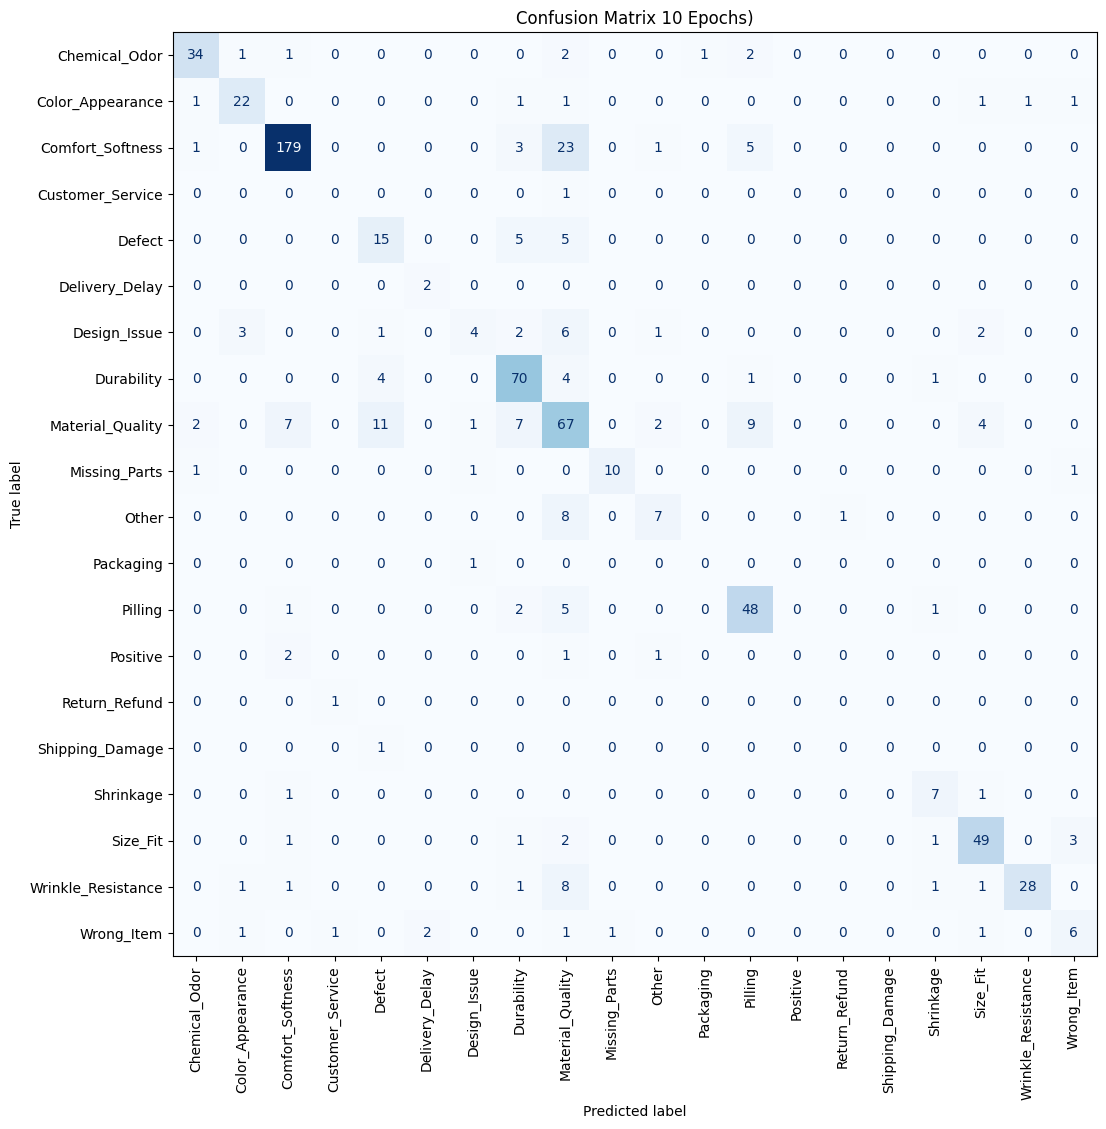

In [86]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(12,12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title(f"Confusion Matrix 10 Epochs)")

plt.show()

In [87]:
trainer.save_model(
    "issue_classifier"
)

tokenizer.save_pretrained(
    "issue_classifier"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('issue_classifier/tokenizer_config.json', 'issue_classifier/tokenizer.json')

In [88]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

tokenizer = AutoTokenizer.from_pretrained(
    "issue_classifier"
)

model = AutoModelForSequenceClassification.from_pretrained(
    "issue_classifier"
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [89]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

review = """
The package arrived crushed and the box was torn.
"""

result = classifier(review)

print(result)

[{'label': 'LABEL_15', 'score': 0.8288556933403015}]


In [90]:
import torch

def predict_issue_with_confidence(text):

    device = model.device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        probs = torch.softmax(
            outputs.logits,
            dim=1
        )

    pred_idx = probs.argmax().item()

    confidence = probs.max().item()

    issue = le.inverse_transform(
        [pred_idx]
    )[0]

    return issue, confidence

In [91]:
predict_issue_with_confidence(
    " Very unhappy with sheet"
)

('Material_Quality', 0.8070836067199707)